In [2]:
import pandas as pd
df = pd.read_csv('data_science_salaries.csv')
df.head()

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           6599 non-null   object
 1   experience_level    6599 non-null   object
 2   employment_type     6599 non-null   object
 3   work_models         6599 non-null   object
 4   work_year           6599 non-null   int64 
 5   employee_residence  6599 non-null   object
 6   salary              6599 non-null   int64 
 7   salary_currency     6599 non-null   object
 8   salary_in_usd       6599 non-null   int64 
 9   company_location    6599 non-null   object
 10  company_size        6599 non-null   object
dtypes: int64(3), object(8)
memory usage: 567.2+ KB


In [4]:
df.describe()

,work_year,salary,salary_in_usd
count,6599.000000,6.599000e+03,6599.000000
mean,2022.818457,1.792833e+05,145560.558569
std,0.674809,5.263722e+05,70946.838070
min,2020.000000,1.400000e+04,15000.000000
25%,2023.000000,9.600000e+04,95000.000000
50%,2023.000000,1.400000e+05,138666.000000
75%,2023.000000,1.875000e+05,185000.000000
max,2024.000000,3.040000e+07,750000.000000


In [5]:
df.head()

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [6]:
df.columns

Index(['job_title', 'experience_level', 'employment_type', 'work_models',
       'work_year', 'employee_residence', 'salary', 'salary_currency',
       'salary_in_usd', 'company_location', 'company_size'],
      dtype='object')

In [7]:
df.isnull().sum()

job_title             0
experience_level      0
employment_type       0
work_models           0
work_year             0
employee_residence    0
salary                0
salary_currency       0
salary_in_usd         0
company_location      0
company_size          0
dtype: int64

In [8]:
df.groupby('experience_level')['salary_in_usd'].mean()

experience_level
Entry-level         84448.916814
Executive-level    189687.346457
Mid-level          119019.812537
Senior-level       162071.063581
Name: salary_in_usd, dtype: float64

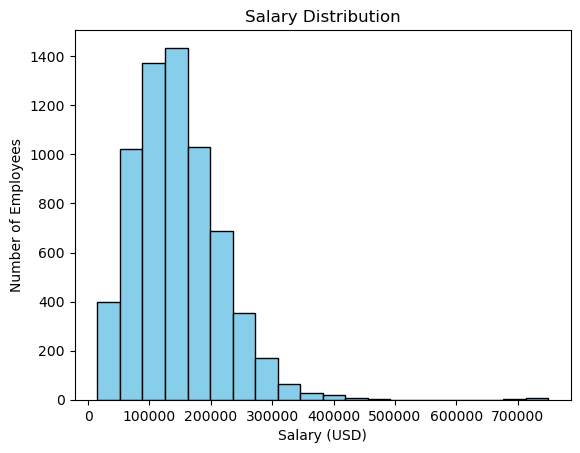

In [11]:
import matplotlib.pyplot as plt

plt.hist(df['salary_in_usd'], bins=20, color='skyblue', edgecolor='black')
plt.title("Salary Distribution")
plt.xlabel("Salary (USD)")
plt.ylabel("Number of Employees")
plt.show()

In [12]:
df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

job_title
Analytics Engineering Manager     399880.000000
Data Science Tech Lead            375000.000000
Managing Director Data Science    280000.000000
AWS Data Architect                258000.000000
Cloud Data Architect              250000.000000
AI Architect                      232058.600000
Director of Data Science          213454.387097
Data Infrastructure Engineer      201375.416667
Data Science Director             201000.000000
ML Engineer                       198223.256637
Name: salary_in_usd, dtype: float64

In [15]:
df.groupby('work_models')['salary_in_usd'].mean()

work_models
Hybrid      83293.502222
On-site    152600.100970
Remote     140550.137837
Name: salary_in_usd, dtype: float64

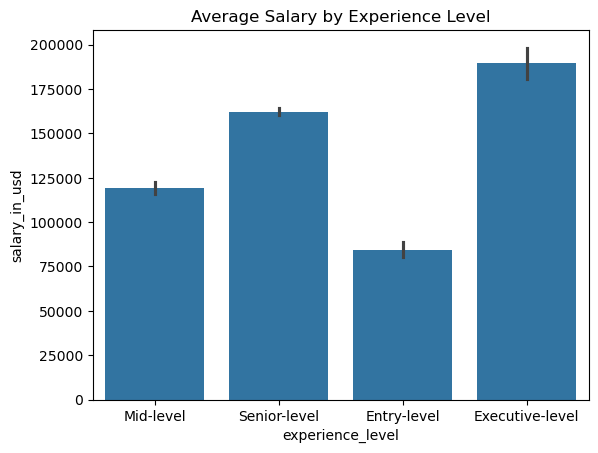

In [18]:
import seaborn as sns

sns.barplot(x='experience_level', y='salary_in_usd', data=df)
plt.title('Average Salary by Experience Level')
plt.show()

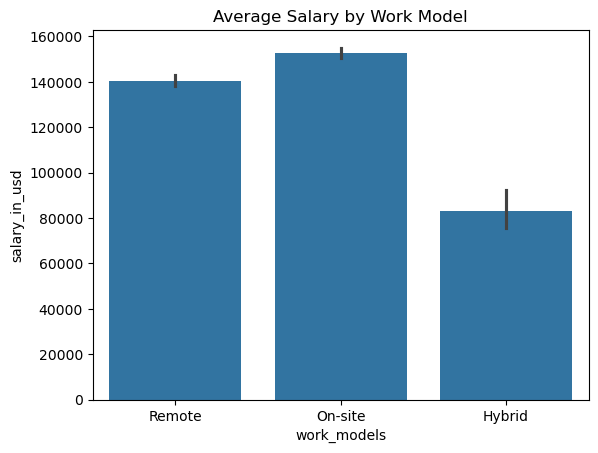

In [17]:
sns.barplot(x='work_models',y='salary_in_usd', data=df)
plt.title("Average Salary by Work Model")
plt.show()

In [19]:
df.groupby(['job_title', 'experience_level'])['salary_in_usd'].mean().unstack()

experience_level,Entry-level,Executive-level,Mid-level,Senior-level
job_title,,,,
AI Architect,NaN,215936.0,NaN,233850.000000
AI Developer,110119.5,NaN,138294.333333,162770.666667
AI Engineer,28296.5,NaN,152988.187500,176705.866667
AI Product Manager,NaN,NaN,NaN,120000.000000
AI Programmer,56858.8,NaN,NaN,120000.000000
...,...,...,...,...
Sales Data Analyst,NaN,NaN,60000.000000,NaN
Software Data Engineer,NaN,NaN,74883.000000,130000.000000
Staff Data Analyst,44753.0,15000.0,179998.000000,NaN


<Axes: xlabel='company_size', ylabel='salary_in_usd'>

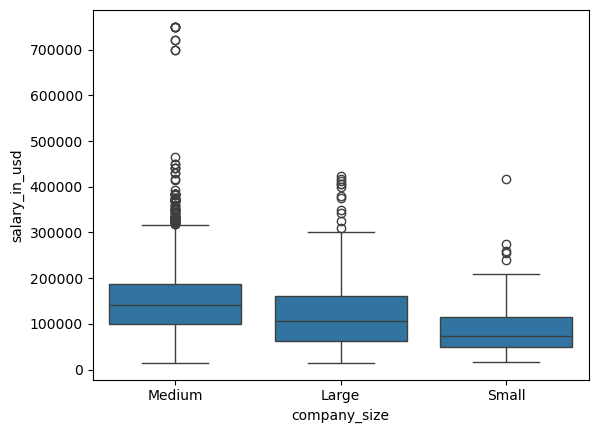

In [20]:
sns.boxplot(x='company_size', y='salary_in_usd', data=df)

In [21]:
df['salary_percentile'] = df['salary_in_usd'].rank(pct=True)
df[df['salary_percentile']> 0.9] # Top 10%

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size,salary_percentile
6,Research Analyst,Entry-level,Full-time,On-site,2024,United States,250000,USD,250000,United States,Medium,0.928550
30,Machine Learning Scientist,Senior-level,Full-time,On-site,2024,United States,252000,USD,252000,United States,Medium,0.933096
32,Machine Learning Engineer,Senior-level,Full-time,On-site,2024,United States,267900,USD,267900,United States,Medium,0.951508
38,Data Scientist,Senior-level,Full-time,On-site,2024,United States,242000,USD,242000,United States,Medium,0.912941
44,Data Scientist,Mid-level,Full-time,Remote,2024,United States,246000,USD,246000,United States,Medium,0.919003
...,...,...,...,...,...,...,...,...,...,...,...,...
6529,Research Scientist,Mid-level,Full-time,On-site,2020,United States,450000,USD,450000,United States,Medium,0.998409
6531,Machine Learning Engineer,Entry-level,Full-time,Hybrid,2020,United States,250000,USD,250000,United States,Large,0.928550
6546,Director of Data Science,Executive-level,Full-time,Remote,2020,United States,325000,USD,325000,United States,Large,0.985983
6554,Data Scientist,Senior-level,Full-time,Remote,2020,United States,412000,USD,412000,United States,Large,0.996666


<Axes: xlabel='experience_level', ylabel='job_title'>

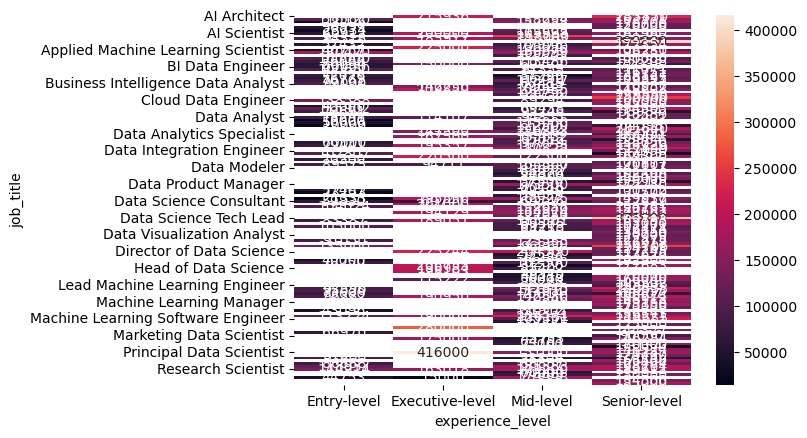

In [24]:
import seaborn as sns
pivot_table = df.pivot_table(values='salary_in_usd', index='job_title', columns='experience_level', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, fmt=".0f")

<Axes: xlabel='experience_level', ylabel='salary_in_usd'>

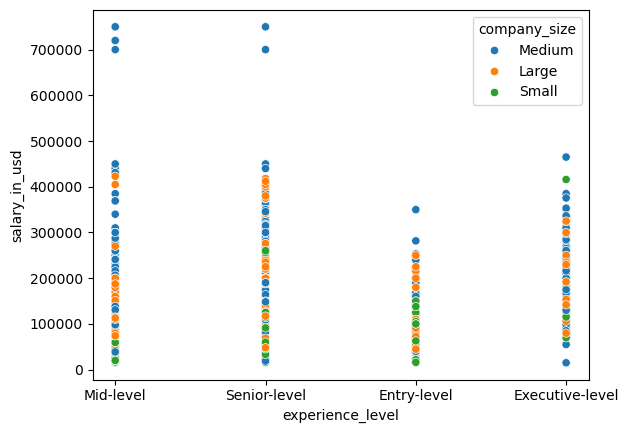

In [25]:
sns.scatterplot(x='experience_level', y='salary_in_usd', hue='company_size', data=df)

<Axes: xlabel='log_salary', ylabel='Count'>

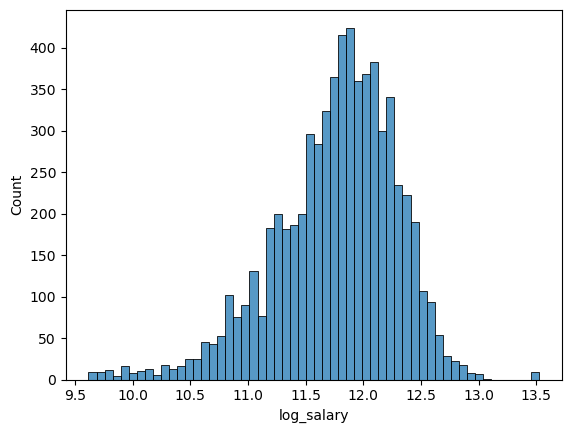

In [26]:
import numpy as np
df['log_salary'] = np.log(df['salary_in_usd'])
sns.histplot(df['log_salary'])

In [31]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Encode experience_level
df['experience_level_encoded'] = le.fit_transform(df['experience_level'])

# Encode company_size
df['company_size_encoded'] = le.fit_transform(df['company_size'])

# Encode work_models
df['work_models_encoded'] = le.fit_transform(df['work_models'])

In [32]:
df.head()

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size,salary_percentile,log_salary,experience_level_encoded,company_size_encoded,work_models_encoded
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium,0.562282,11.905643,2,1,2
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium,0.264358,11.499840,2,1,2
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium,0.517957,11.849626,3,1,2
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium,0.283831,11.513145,3,1,2
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium,0.389680,11.695247,2,1,1


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
X = df[['experience_level_encoded', 'company_size_encoded', 'work_models_encoded']]
y = df['salary_in_usd']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

In [36]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 73983.51903687314
R² Score: 0.06864720163439919


In [37]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 73983.51903687314
R² Score: 0.06864720163439919


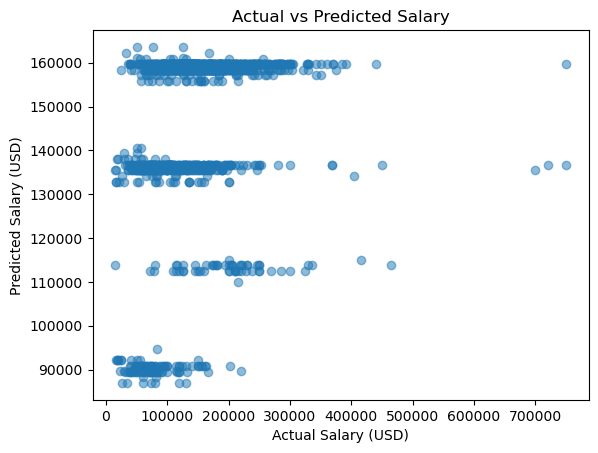

In [38]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")
plt.title("Actual vs Predicted Salary")
plt.show()

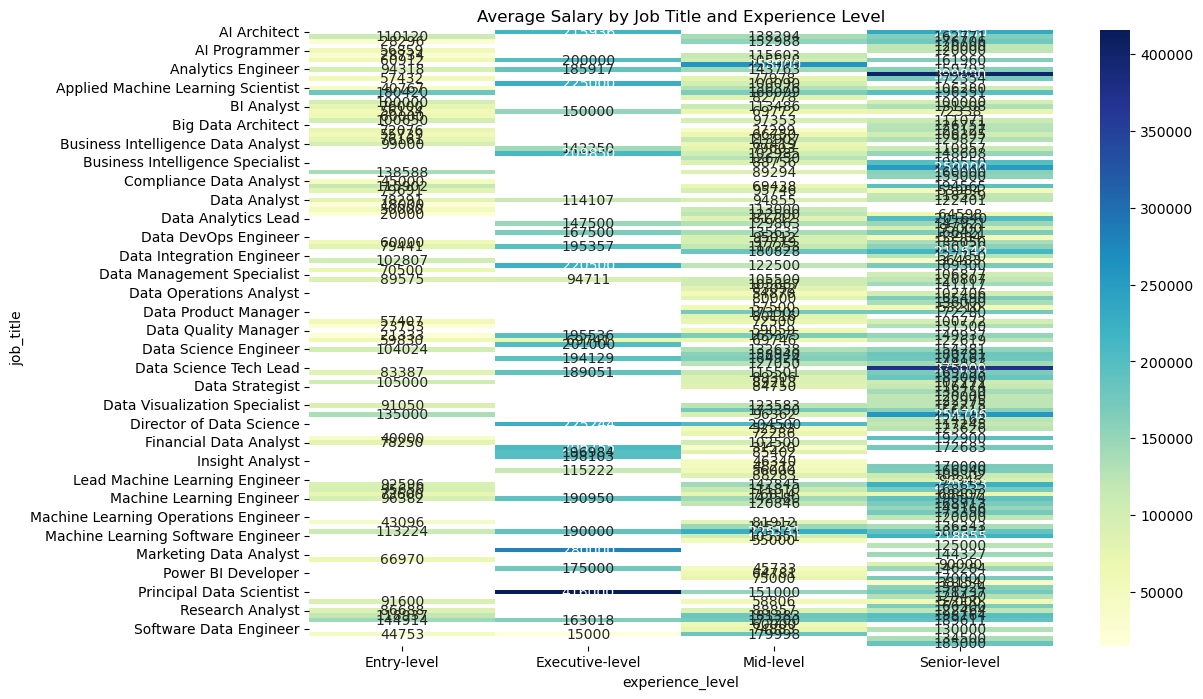

In [39]:
import seaborn as sns

pivot_table = df.pivot_table(values='salary_in_usd', index='job_title', columns='experience_level', aggfunc='mean')
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Salary by Job Title and Experience Level")
plt.show()

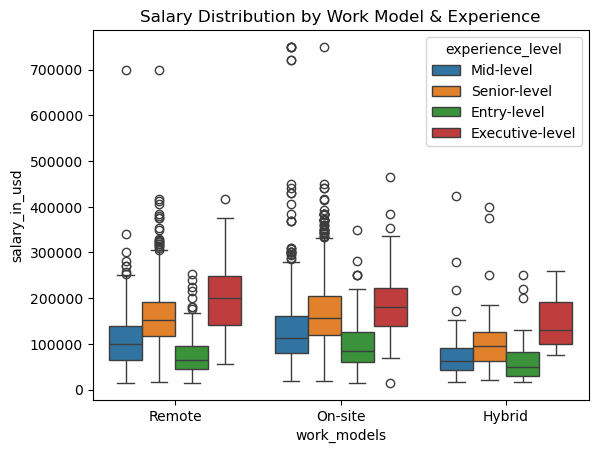

In [40]:
sns.boxplot(x='work_models', y='salary_in_usd', hue='experience_level', data=df)
plt.title("Salary Distribution by Work Model & Experience")
plt.show()

In [41]:
plt.savefig("salary_workmodel_experience.png")

<Figure size 640x480 with 0 Axes>

Data Loaded Successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           6599 non-null   object
 1   experience_level    6599 non-null   object
 2   employment_type     6599 non-null   object
 3   work_models         6599 non-null   object
 4   work_year           6599 non-null   int64 
 5   employee_residence  6599 non-null   object
 6   salary              6599 non-null   int64 
 7   salary_currency     6599 non-null   object
 8   salary_in_usd       6599 non-null   int64 
 9   company_location    6599 non-null   object
 10  company_size        6599 non-null   object
dtypes: int64(3), object(8)
memory usage: 567.2+ KB
None
         work_year        salary  salary_in_usd
count  6599.000000  6.599000e+03    6599.000000
mean   2022.818457  1.792833e+05  145560.558569
std       0.674809  5.263722e+05   70946.8

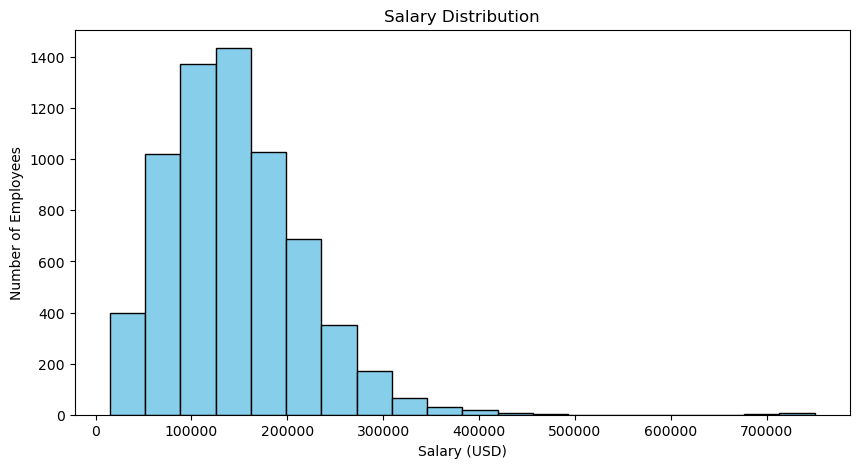

<Figure size 640x480 with 0 Axes>

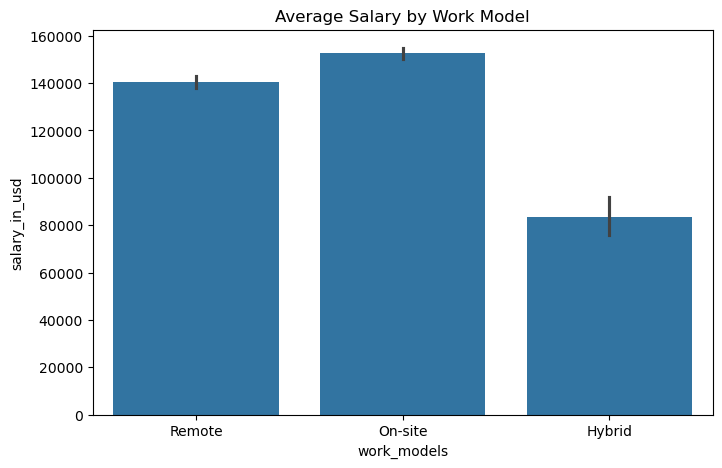

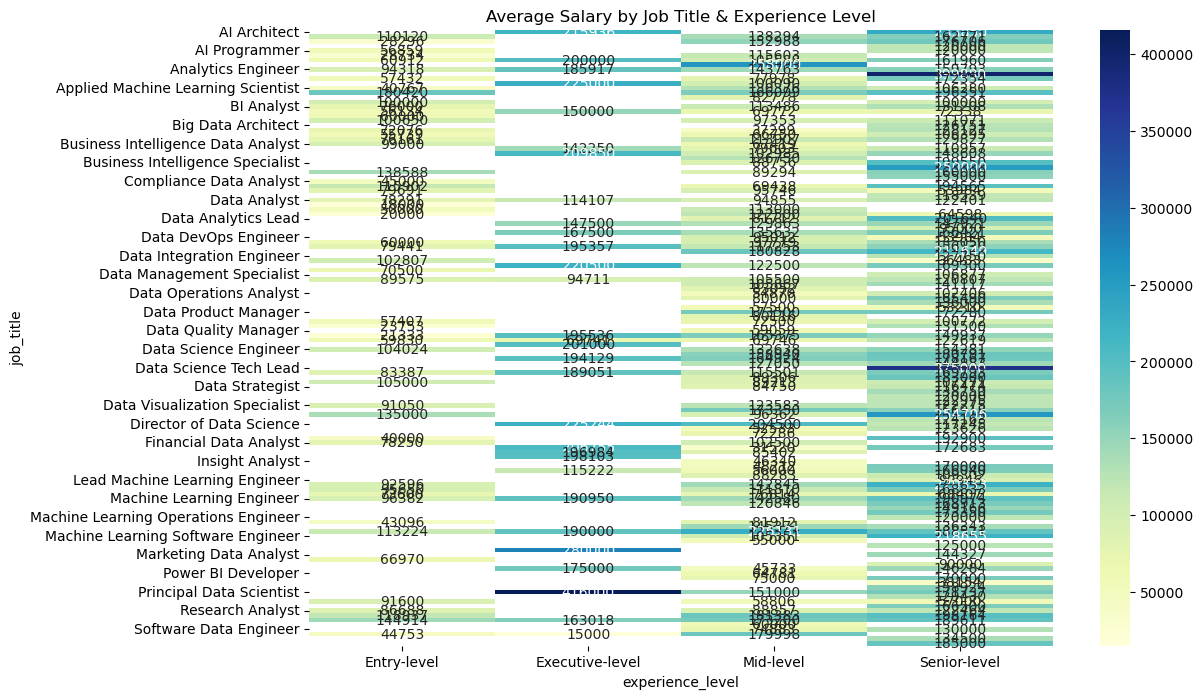

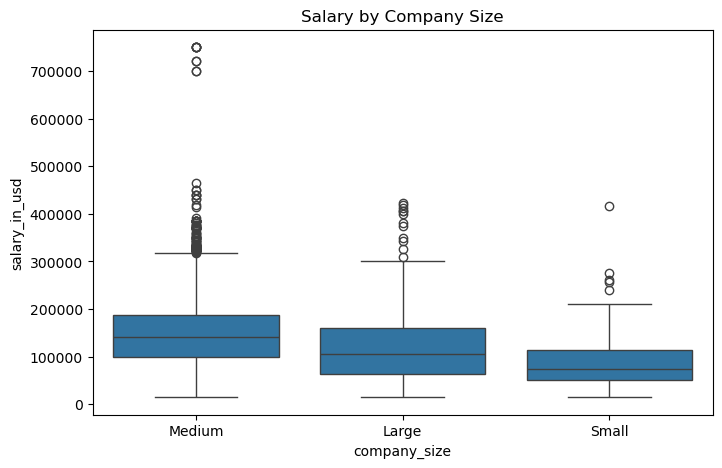

RMSE: 73983.52
R² Score: 0.07


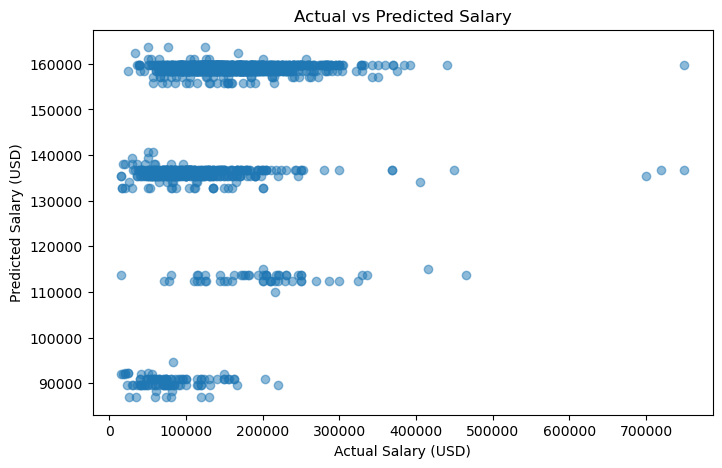


--- Insights & Recommendations ---
1. Salary increases with experience level.
2. Remote jobs slightly pay higher on average.
3. Top paying job titles:  ['Analytics Engineering Manager', 'Data Science Tech Lead', 'Managing Director Data Science', 'AWS Data Architect', 'Cloud Data Architect', 'AI Architect', 'Director of Data Science', 'Data Infrastructure Engineer', 'Data Science Director', 'ML Engineer']
4. Big companies tend to pay more than smaller companies.
5. Linear Regression model can roughly predict salaries based on experience, company size, and work model.
Processed Data Saved!


In [42]:
# -------------------------------
# Step 0: Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# Step 1: Load Data
# -------------------------------
df = pd.read_csv('data_science_salaries.csv')
print("Data Loaded Successfully!")
df.head()

# -------------------------------
# Step 2: Explore Data
# -------------------------------
print(df.info())
print(df.describe())

# Check missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# -------------------------------
# Step 3: Advanced Analysis
# -------------------------------

# 3.1 Average Salary by Experience Level
avg_salary_exp = df.groupby('experience_level')['salary_in_usd'].mean()
print("\nAverage Salary by Experience Level:\n", avg_salary_exp)

# 3.2 Top Paying Job Titles
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
print("\nTop Paying Job Titles:\n", top_jobs)

# 3.3 Salary Distribution Histogram
plt.figure(figsize=(10,5))
plt.hist(df['salary_in_usd'], bins=20, color='skyblue', edgecolor='black')
plt.title("Salary Distribution")
plt.xlabel("Salary (USD)")
plt.ylabel("Number of Employees")
plt.show()
plt.savefig("salary_distribution.png")

# 3.4 Remote vs On-site Salary Comparison
plt.figure(figsize=(8,5))
sns.barplot(x='work_models', y='salary_in_usd', data=df)
plt.title("Average Salary by Work Model")
plt.savefig("salary_by_workmodel.png")
plt.show()

# 3.5 Heatmap: Job Title vs Experience Level
pivot_table = df.pivot_table(values='salary_in_usd', index='job_title', columns='experience_level', aggfunc='mean')
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Salary by Job Title & Experience Level")
plt.savefig("heatmap_job_exp.png")
plt.show()

# 3.6 Salary by Company Size
plt.figure(figsize=(8,5))
sns.boxplot(x='company_size', y='salary_in_usd', data=df)
plt.title("Salary by Company Size")
plt.savefig("salary_by_company_size.png")
plt.show()

# -------------------------------
# Step 4: Prepare Data for ML
# -------------------------------

# Encode categorical columns
le = LabelEncoder()
df['experience_level_encoded'] = le.fit_transform(df['experience_level'])
df['company_size_encoded'] = le.fit_transform(df['company_size'])
df['work_models_encoded'] = le.fit_transform(df['work_models'])

# Features & Target
X = df[['experience_level_encoded', 'company_size_encoded', 'work_models_encoded']]
y = df['salary_in_usd']

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# Step 5: Train Linear Regression Model
# -------------------------------
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Evaluate Model
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Visualize Predictions vs Actual
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")
plt.title("Actual vs Predicted Salary")
plt.savefig("predicted_vs_actual.png")
plt.show()

# -------------------------------
# Step 6: Insights Summary
# -------------------------------
print("\n--- Insights & Recommendations ---")
print("1. Salary increases with experience level.")
print("2. Remote jobs slightly pay higher on average.")
print("3. Top paying job titles: ", list(top_jobs.index))
print("4. Big companies tend to pay more than smaller companies.")
print("5. Linear Regression model can roughly predict salaries based on experience, company size, and work model.")

# -------------------------------
# Step 7: Save Data (Optional)
# -------------------------------
df.to_csv("data_science_salaries_processed.csv", index=False)
print("Processed Data Saved!")